# Using the TEM class for data inversion
## Profile data with sTEM profiler

We make use of the data published by Madsen et al. (2026), made publicly available on [Zenodo](https://doi.org/10.5281/zenodo.16894039). Here we focus on the sTEM profiler data with 3x3m loops, separated by 13m. Here, we used the file `sTEM.xyz` in the folder `SallingKirkeby_sTEM_0034_Profier`, renamed as `profiler.xyz`.

We import the main class `TEM`.

In [29]:
import numpy as np
from pytem import TEM
from pygimli.viewer.mpl.overlayimage import underlayBKGMap

In [67]:
thk = np.arange(2., 16, 2)
tem = TEM("sTEM.xyz", thk=thk)
print(tem)
print(tem.t)

TEM profile with 28 soundings
29 times (1.232756e-05-0.002356259)
[1.232756e-05 1.519689e-05 1.873406e-05 2.309454e-05 2.846994e-05
 3.509650e-05 4.326544e-05 5.333575e-05 2.509911e-05 3.149826e-05
 3.952890e-05 4.960701e-05 6.225457e-05 7.812670e-05 9.804552e-05
 1.230427e-04 1.544131e-04 1.937816e-04 2.431872e-04 3.051890e-04
 3.829986e-04 4.806461e-04 6.031893e-04 7.569756e-04 9.499705e-04
 1.192170e-03 1.496121e-03 1.877564e-03 2.356259e-03]


The file contains 104 soundings with 28 time gates between 10µs and 2ms, 8 for the low moment and 20 for the high moment.
First, we have a look into the transmitter waveforms.

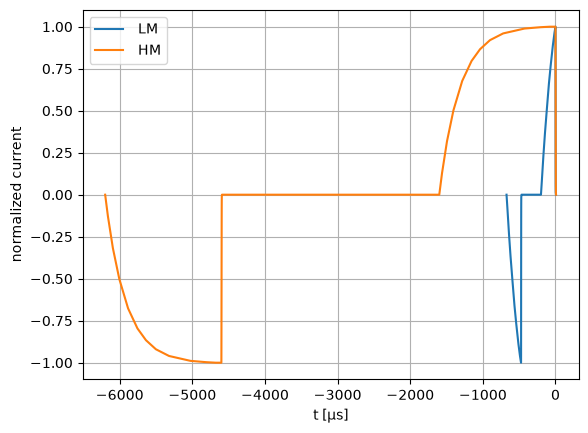

In [69]:
ax = tem.showWaveform();

While the high moment has a time interval of 4.6ms between shots of different polarity, it is 475µs for the low moment.
To have a closer look at the shutoff, one has to set the limits, showing a 2.5µs ramp for the low moment and a 5.5µs ramp for the high moment.

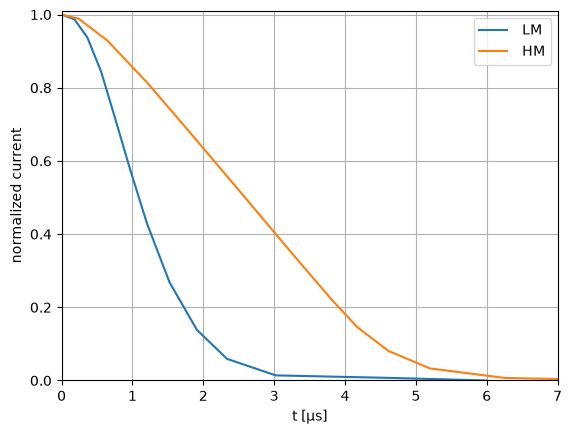

In [61]:
ax = tem.showWaveform(shutoff=True);
ax.set_xlim(0, 7); # now in µs

In the file, there are also the GPS positions that can be shown:

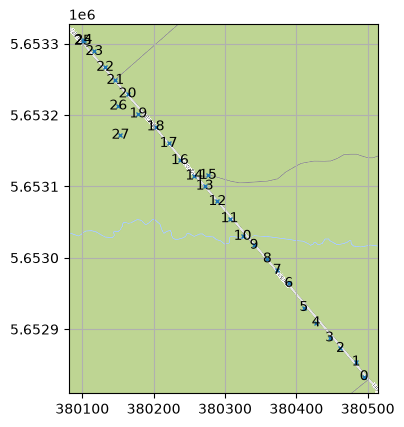

In [4]:
ax = tem.showPositions(every=1)
underlayBKGMap(ax, utmzone=33)

By comparing to Figure 2, the first 20 soundings correspond to the beginnning of profile B, whose results are provided in Figure 5c (first 1200m). We extract those first soundings by

In [66]:
tem.filter(nmin=1)
print(tem)

TEM profile with 27 soundings
29 times (1.232756e-05-0.002356259)


We can show a single sounding by `showSounding()`

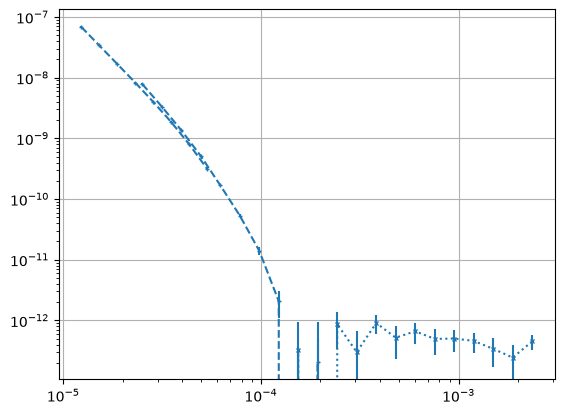

In [6]:
tem.showSounding(n=13);

or, transferred to apparent resistivity

<Axes: >

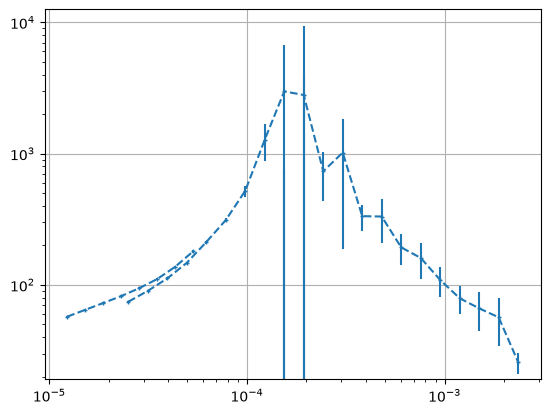

In [7]:
tem.showSounding(n=13, rhoa=True)

For viewing a specific gate spatially, one can use `showRhoa()` with the gate number.

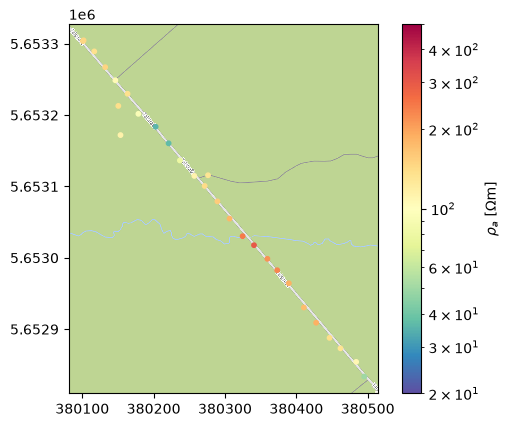

In [64]:
ax = tem.showRhoa(nt=10, cMin=20, cMax=500, orientation="vertical");
underlayBKGMap(ax, utmzone=33)

To view all data, we can use `showRhoa()`

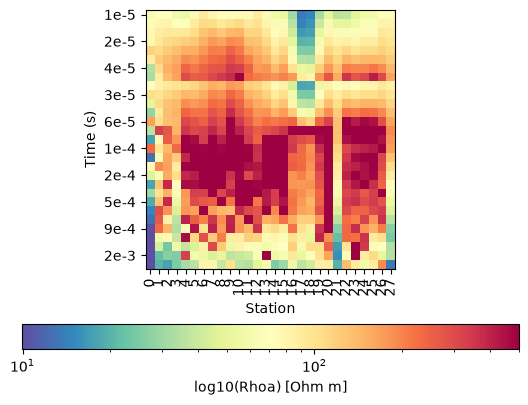

In [38]:
tem.showRhoa();

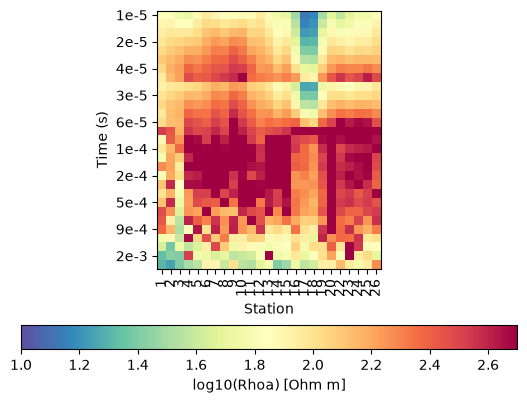

In [9]:
tem.filter(n=[21, 27])
tem.showRhoa();

Showing all soundings by

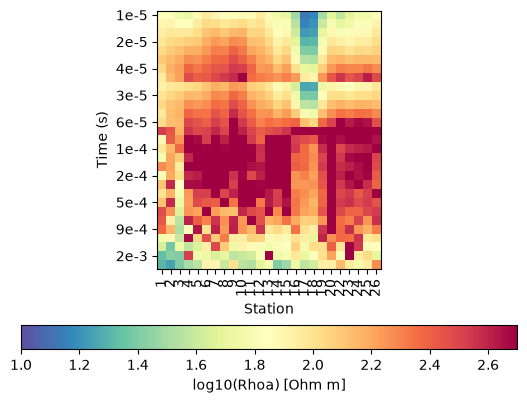

In [10]:
tem.filter(tmax=3e-3)
tem.showRhoa();

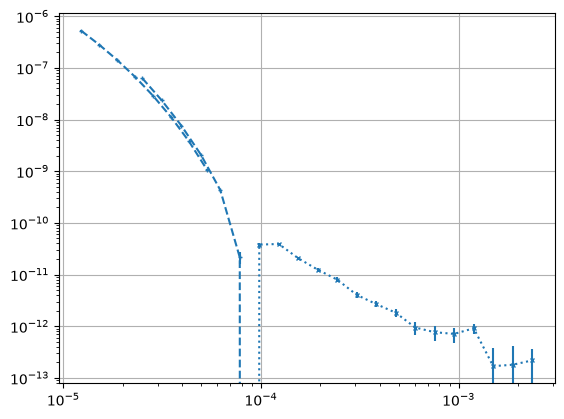

In [11]:
tem.showSounding(17);

we observe them running into noise at around 1ms, which can be filtered by `.filter(tmax=1e-3)`. (TODO)

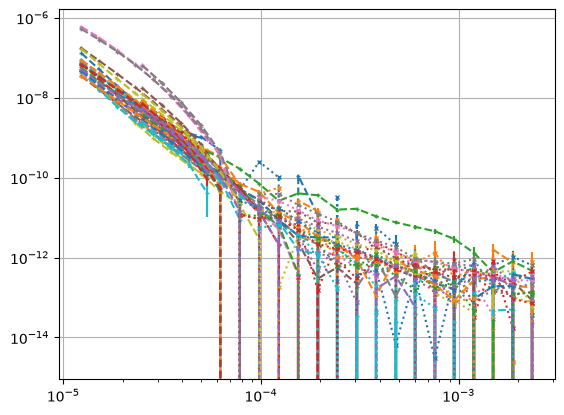

In [12]:
tem.showSoundings();

First, we invert a single sounding.

and see the change from the resistive (>100$\Omega$m) top layer to the conductive layer below (cf. Fig. 4c).
For inverting all soundings subsequently, we use 

<Axes: xlabel='Station', ylabel='Time (s)'>

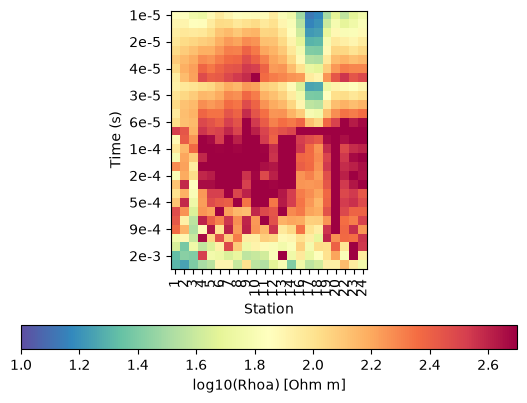

In [13]:
tem.filter(n=[15, 25, 26])
# tem.filter(nmax=22)
tem.showRhoa()

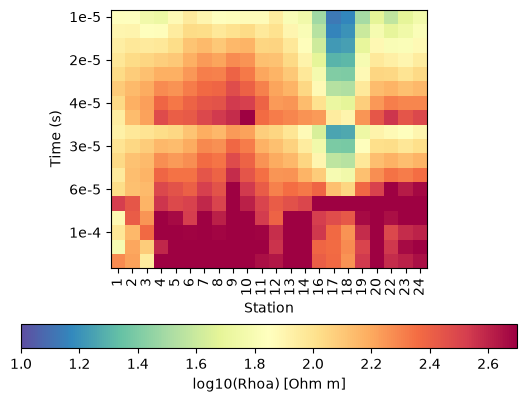

In [28]:
tem.filter(tmax=2e-4)
tem.showRhoa();

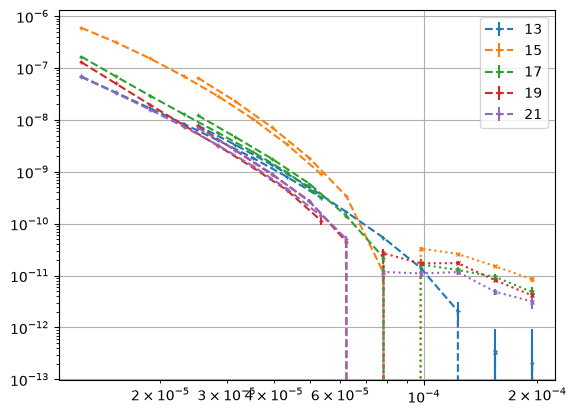

In [27]:
ax = tem.showSoundings(nn=[13, 15, 17, 19, 21])
ax.legend();

16/07/26 - 17:00:28 - pyGIMLi - INFO - Starting inversion.
16/07/26 - 17:00:28 - pyGIMLi - INFO - fop: <pytem.temmodelling.TEMRhoModelling object at 0x000001176F49D300>
16/07/26 - 17:00:28 - pyGIMLi - INFO - Data transformation: Identity transform
16/07/26 - 17:00:28 - pyGIMLi - INFO - Model transformation: Logarithmic transform
16/07/26 - 17:00:28 - pyGIMLi - INFO - min/max (data): 3.7e-12/8.7e-08
16/07/26 - 17:00:28 - pyGIMLi - INFO - min/max (error): 3%/1.0e+10%
16/07/26 - 17:00:28 - pyGIMLi - INFO - min/max (start model): 250/250


--------------------------------------------------------------------------------


16/07/26 - 17:00:34 - pyGIMLi - INFO - inv.iter 0 ... chi² =  286.94


--------------------------------------------------------------------------------
inv.iter 1 ... 

16/07/26 - 17:00:36 - pyGIMLi - INFO - chi² =  228.52 (dPhi = 20.33%) lam: 20.0


...

--------------------------------------------------------------------------------
inv.iter 13 ... 

16/07/26 - 17:01:48 - pyGIMLi - INFO - chi² =   15.66 (dPhi = 12.82%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 14 ... 

16/07/26 - 17:01:53 - pyGIMLi - INFO - chi² =   15.47 (dPhi = 0.06%) lam: 20.0


################################################################################
#                Abort criterion reached: dPhi = 0.06 (< 2.0%)                 #
################################################################################


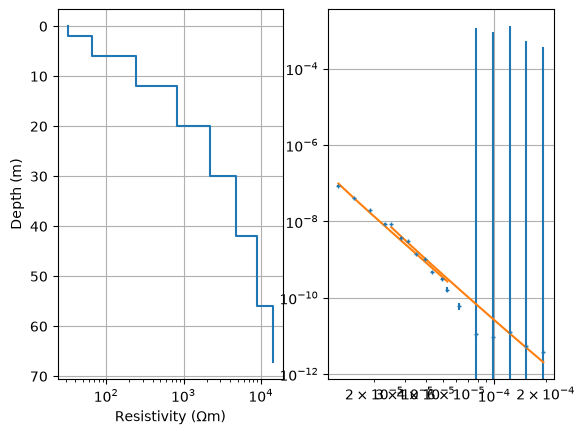

In [15]:
tem.invertSounding(20);

In [ ]:
tem.invertAll();

By default, the elevation is extracted and the profile distance is computed by summing the distances.
By calling `showResults(usepos='x')`, one can also use Easting or Northing (`usepos='y'`) for display or `usepos=False` for not using any position. You can also specify the color map and color range.

In [ ]:
tem.showResults(cMin=50, cMax=3000, cMap="Spectral_r", zMax=100)